# Objetivo 1: instalar y correr MAFFT y HMMER

### a-d) corra todos los comandos anteriores y analice un poco el archivo “secuencias_modelo.hmm”, puede identificar en él los parámetros que usted conoce debe poseer el modelo (probabilidad de emisión de cada residuo en cada columna (estado match), columnas importantes, probabilidad de inserción, etc).

In [1]:
from Bio import AlignIO

input_handle = open("Archivos/PF11563.alignment.seed", "r")
output_handle = open("Archivos/seed.fasta", "w")

alignments = AlignIO.parse(input_handle, "stockholm")
AlignIO.write(alignments, output_handle, "fasta")

input_handle.close()
output_handle.close()

![Dominios Blast](Img/Ej1_HMM.jpg)

![Dominios Blast](Img/Ej1_Pos93.jpg)
Al inspeccionar el archivo, se pueden identificar los parámetros mas importantes del modelo:  
- $\textbf{Columnas importantes:}$ El parámetro LENG 157 indica que el perfil consta de 157 posiciones conservadas y NSEQ 62 confirma que las 62 secuencias del alineamiento semilla fueron utilizadas para entrenar el perfil del HMM.
- $\textbf{Probabilidad de Match:}$ La primera línea de cada posición nos da la probabilidad de encontrar cada uno de los 20 aminoácidos. Por ejemplo, en la posición 93, la Histidina presenta un valor extremadamente bajo de 0.71087, reflejando una altísima conservación biológica en esa columna.
- $\textbf{Probabilidad de Inserción:}$ La segunda línea de cada posición define la probabilidad de que se emita cada aminoácido en caso de ocurrir una inserción en esa posición puntual.  
- $\textbf{Transiciones:}$ La tercera línea de cada bloque establece las probabilidades de pasar de un estado a otro, ya sea manteniendo la coincidencia, abriendo un gap o introduciendo una inserción.

### e) analice el archivo de salida de HMMsearch, trate de identificar dónde están los resultados obtenidos para cada secuencia query, y de ellos donde está el E-value, la cobertura, etc.

Al inspeccionar el archivo de salida generado por hmmsearch, se identifican dos secciones principales de resultados, __"Scores for complete sequences"__ y __"Domain annotation for each sequence"__. A modo de ejemplo, se puede analizar la proteína tr|G0RZQ1|G0RZQ1_CHATD

![Dominios Blast](Img/Ej1_BusquedaGlobal.jpg)
En la primera sección se observan los resultados integrales por secuencia. Para la proteína G0RZQ1, se identifica un E-value global de $1.1e^{-52} $ indicando una alta significancia estadística y un Score total de 179.2. La columna N nos dice que se detectó un solo dominio globina en toda esa secuencia.
![Dominios Blast](Img/Ej1_BusquedaLocal.jpg)
En la segunda sección se ve el alineamiento de cada dominio específico. Aquí vemos que el Score del dominio es 178.9 y su i-Evalue $1.3e^{-52} $.  
Finalmente, se puede determinar la cobertura de cada alineamiento:

- Las columnas hmmfrom / hmm to indican que la secuencia logró alinear casi todo el modelo (desde el nodo 3 hasta el 157).
- Las columnas alifrom / ali to nos dan las coordenadas exactas de corte: el dominio protoglobina se ubica entre los aminoácidos 20 y 200 de la secuencia original de la proteína.


# Objetivo 2: Recuperar los dominios con Python

### a) Histograma de puntajes de dominio. El primer objetivo busca implementar un script en python que grafique un histograma de puntajes de secuencia POR DOMINIO

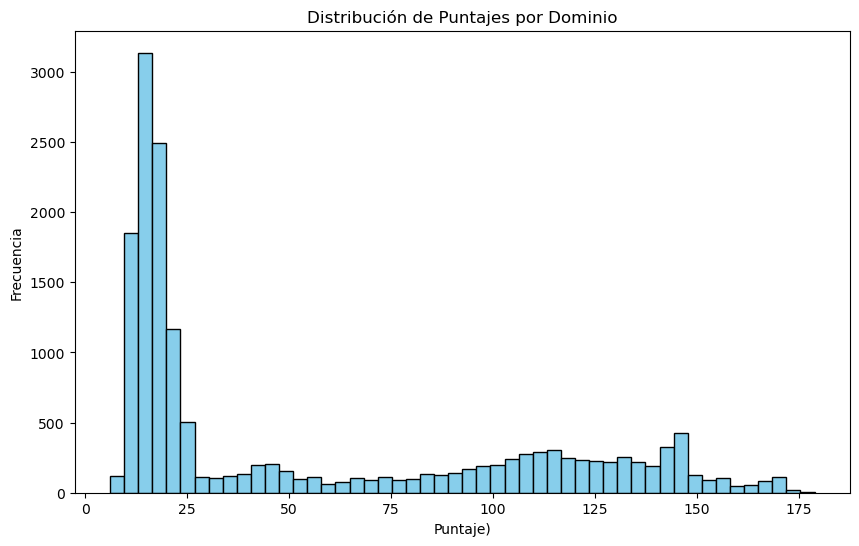

In [2]:
from Bio import SearchIO
from Bio import SeqIO
import matplotlib.pyplot as plt

resultados = SearchIO.read('Archivos/busqueda.out', 'hmmer3-text')
puntajesLista = []

for hit in resultados:
    for hsp in hit:
        puntajesLista.append(hsp.bitscore)

plt.figure(figsize=(10, 6))
plt.hist(puntajesLista, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Puntajes por Dominio')
plt.xlabel('Puntaje)')
plt.ylabel('Frecuencia')

plt.show()

### b) Desarrolle en python un código que utilice el puntaje de corte recién establecido para extraer los dominios búscados en las secuencias correspondientes.

Definimos un puntaje de corte de 40 viendo la distribución del histograma

In [3]:
from Bio import SearchIO
def extraerPosiciones(puntaje_corte):
    listaLimites = []
    
    for hit in resultados:
        for hsp in hit:
            if hsp.bitscore > puntaje_corte:
                listaLimites.append([hit.id, hsp.hit_start, hsp.hit_end]) 
                
    return listaLimites


def guardarDominios(listaLimites):
    registrosFasta = list(SeqIO.parse("Archivos/globin_full_sequences.fasta", "fasta"))
    registrosModificados = []
    
    for registro in registrosFasta:
        contador = 0
        coincidencia = False
        while not coincidencia and contador < len(listaLimites):
            idBuscado, inicio, fin = listaLimites[contador]
            
            # Si hay coincidencia entre el ID del Fasta y el de nuestra búsqueda
            if idBuscado == registro.id:
                coincidencia = True
                dominioRecortado = registro[inicio:fin]
                partesId = registro.id.split('|')
                uniprotId = partesId[1] if len(partesId) > 1 else registro.id                
                nuevoId = f"{uniprotId}/{inicio+1}-{fin}" 
                dominioRecortado.id = nuevoId                
                registrosModificados.append(dominioRecortado)
                
                listaLimites.pop(contador)
            
            else:
                contador += 1

    SeqIO.write(registrosModificados, "Archivos/dominios_protoglobina_recortados.fasta", "fasta")
    print(f"Se recuperaron y guardaron {len(registrosModificados)} dominios.")

limitesRecuperados = extraerPosiciones(40)
guardarDominios(limitesRecuperados)

Se recuperaron y guardaron 6473 dominios.


### c) Responda:
- __¿Cuántos dominios de protoglobina logró recuperar de la minería de datos?__  
Se lograron recuperar 6473 dominios de protoglobina
- __¿Puede afirmar que recuperó todos y que no dejó alguno afuera?__  
No es posible afirmarlo, la elección de un umbral de corte manual siempre implica un compromiso entre sensibilidad y especificidad. Al establecer un corte arbitrario de 40 para evitar incorporar ruido, aumentamos la especificidad, pero disminuimos la sensibilidad. Es altamente probable que secuencias de verdaderas protoglobinas que estén muy mutadas hayan quedado como falsos negativos.
- __¿O que solo recuperó dominios protoglobina y que no incorporó dominios globina de otro tipo? ¿Por qué?__  
Tampoco se puede afirmar, si existe una alta conservación de otras familias de globinas que compartan motivos muy similares con el perfil de la protoglobina, podrían haber superado el umbral de 40 puntos, incorporándose a nuestro set como falsos positivos

# Objetivo 3: comparar y analizar alineamientos

### a) Parsee los MSAs hechos con hmmalign y MAFFT y busque la posición de la histidina F8 (el residuo más conservado y característico de todas las globinas), y calcule la proporción de gaps en el MSA para esa posición. Compare el porcentaje de histidinas en esa columna entre los dos MSAs obtenidos (porMAFFT y hmmalign), y la proporción de gaps obtenida. ¿En qué posición está la histidina F8 en cada MSA? ¿Está en la misma posición en ambos casos? ¿En cuál MSA hay más presencia de gaps?

#### Primero hacemos MAFFT

In [4]:
import pandas as pd
from Bio import AlignIO
# hacemos el parseo
align_mafft = AlignIO.read("Archivos/alin_mafft_protoglobina.fasta", "fasta")
align_mafft = pd.DataFrame(align_mafft)
align_mafft.shape
cantidad_columnas = align_mafft.shape[1]
#buscamos la histidina F8
sumas = []
for k in range(cantidad_columnas):
  sumas.append(align_mafft[k].value_counts().get("H", 0))

columna_elegida = sumas.index(max(sumas))

print("Elegimos la columna:",columna_elegida)

# Calculamos proporción de gaps y de histidina
total_de_filas = align_mafft.shape[0]
gaps_en_columna_elegida = align_mafft[columna_elegida].value_counts().get("-", 0)
proporcion_de_gaps = (gaps_en_columna_elegida/total_de_filas) * 100
porcentaje_hmax = (max(sumas)/total_de_filas) *100
print(f"Porcentaje de Histidinas en esta columna: {porcentaje_hmax:.2f}%")
print(f"La proporción de gaps es de {proporcion_de_gaps:.2f}%")



Elegimos la columna: 419
Porcentaje de Histidinas en esta columna: 92.41%
La proporción de gaps es de 0.28%


#### Ahora hmmalign

In [5]:
import pandas as pd
from Bio import AlignIO
# hacemos el parseo
align_hmmalign = AlignIO.read("Archivos/alin_hmm_protoglobina.sto", "stockholm")
align_hmmalign = pd.DataFrame(align_hmmalign)
align_hmmalign.shape
cantidad_columnas = align_hmmalign.shape[1]
#buscamos la histidina F8
sumas = []
for k in range(cantidad_columnas):
  sumas.append(align_hmmalign[k].value_counts().get("H", 0))

columna_elegida = sumas.index(max(sumas))

print("Elegimos la columna:",columna_elegida)

# Calculamos proporción de gaps y de histidina
total_de_filas = align_hmmalign.shape[0]
gaps_en_columna_elegida = align_hmmalign[columna_elegida].value_counts().get("-", 0)
porcentaje_hmax2 = (max(sumas)/total_de_filas) *100
proporcion_de_gaps = (gaps_en_columna_elegida/total_de_filas) * 100
print(f"Porcentaje de Histidinas en esta columna: {porcentaje_hmax2:.2f}%")
print(f"La proporción de gaps es de {proporcion_de_gaps:.2f}%")

Elegimos la columna: 267
Porcentaje de Histidinas en esta columna: 92.35%
La proporción de gaps es de 0.14%


Cómo podemos observar, cada MSA eligió otra columna. En el caso de MAFFT fue la columna 419 mientras que en el de hmmalign fue la 267. Si bien detectamos que el porcentaje de histidinas dio casi igual, notamos que la proporción de gaps en el segundo caso fue mucho menor; la mitad, de hecho.  

### Ejercicio 3b. Minería de datos.
PFAM posee en su base de datos 3 dominios globina, el ya utilizado protoglobina, y los
denominados “Globin” y “Bac_globin”.
}

#### 1) Descargue los seeds de éstas dos familias de globinas en Pfam, genere los HMM y corra hmmsearch con cada HMM nuevo contra el set de globinas.

#### 2) Genere los histogramas de puntaje de dominio y establezca un umbral de corte para luego extraer los dominios.

#### Globina

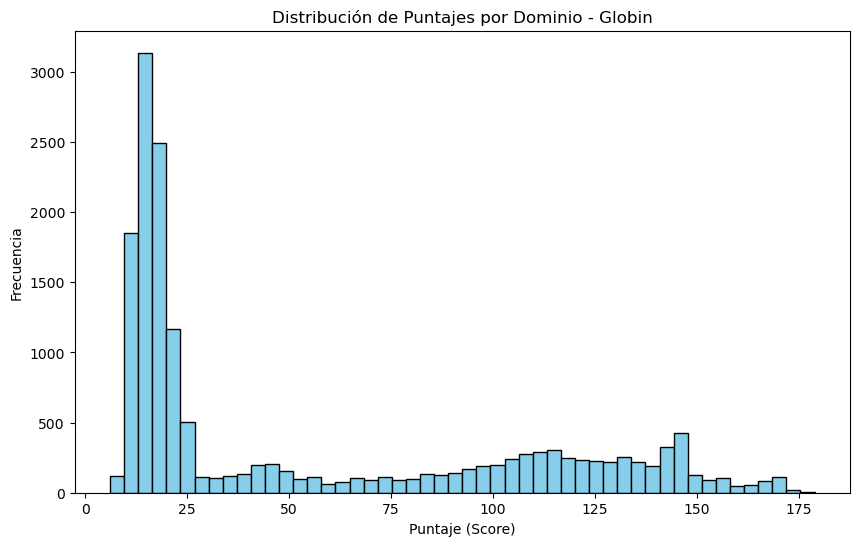

In [6]:
resultados_globin = SearchIO.read('Archivos/resultados_globin.out', 'hmmsearch3-domtab')
puntajesLista2 = []

for hit in resultados_globin:
    for hsp in hit:
        puntajesLista2.append(hsp.bitscore)

plt.figure(figsize=(10, 6))
plt.hist(puntajesLista, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Puntajes por Dominio - Globin')
plt.xlabel('Puntaje (Score)')
plt.ylabel('Frecuencia')
plt.show()

En este caso definimos un umbral de corte de 35

In [7]:
from Bio import SearchIO
from Bio import SeqIO
resultados = SearchIO.read("Archivos/resultados_globin.out", "hmmsearch3-domtab")

def extraerPosiciones(puntaje_corte):
    listaLimites = []
    
    for hit in resultados:
        for hsp in hit:
            if hsp.bitscore > puntaje_corte:
                listaLimites.append([hit.id, hsp.hit_start, hsp.hit_end]) 
                
    return listaLimites

def guardarDominios(listaLimites):
    registrosFasta = list(SeqIO.parse("Archivos/globin_full_sequences.fasta", "fasta"))
    registrosModificados = []
    
    for registro in registrosFasta:
        contador = 0
        coincidencia = False
        while not coincidencia and contador < len(listaLimites):
            idBuscado, inicio, fin = listaLimites[contador]
            if idBuscado == registro.id:
                coincidencia = True
                dominioRecortado = registro[inicio:fin]
                partesId = registro.id.split('|')
                uniprotId = partesId[1] if len(partesId) > 1 else registro.id                
                nuevoId = f"{uniprotId}/{inicio+1}-{fin}" 
                dominioRecortado.id = nuevoId                
                registrosModificados.append(dominioRecortado)
                
                listaLimites.pop(contador)
            
            else:
                contador += 1
    SeqIO.write(registrosModificados, "Archivos/dominios_globin_recortados.fasta", "fasta")
    print(f"Se recuperaron y guardaron {len(registrosModificados)} dominios.")

limitesRecuperados = extraerPosiciones(35)
guardarDominios(limitesRecuperados)

Se recuperaron y guardaron 16645 dominios.


#### Bac_Globin

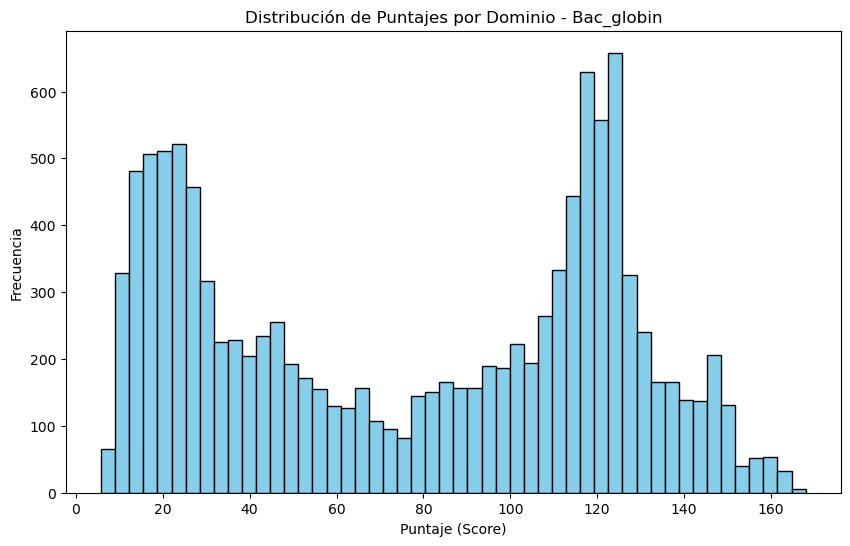

In [8]:
resultados_bac = SearchIO.read('Archivos/resultados_bac_globin.out', 'hmmsearch3-domtab')
puntajes_bac = []

for hit in resultados_bac:
    for hsp in hit:
        puntajes_bac.append(hsp.bitscore)

plt.figure(figsize=(10, 6))
plt.hist(puntajes_bac, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Puntajes por Dominio - Bac_globin')
plt.xlabel('Puntaje (Score)')
plt.ylabel('Frecuencia')
plt.show()

En este caso determinamos un umbral de corte de 40.

In [11]:
from Bio import SearchIO
from Bio import SeqIO
resultados = SearchIO.read("Archivos/resultados_bac_globin.out", "hmmsearch3-domtab")

def extraerPosiciones(puntaje_corte):
    listaLimites = []
    
    for hit in resultados:
        for hsp in hit:
            if hsp.bitscore > puntaje_corte:
                listaLimites.append([hit.id, hsp.hit_start, hsp.hit_end]) 
                
    return listaLimites

def guardarDominios(listaLimites):
    registrosFasta = list(SeqIO.parse("Archivos/globin_full_sequences.fasta", "fasta"))
    registrosModificados = []
    
    for registro in registrosFasta:
        contador = 0
        coincidencia = False
        while not coincidencia and contador < len(listaLimites):
            idBuscado, inicio, fin = listaLimites[contador]
            if idBuscado == registro.id:
                coincidencia = True
                dominioRecortado = registro[inicio:fin]
                partesId = registro.id.split('|')
                uniprotId = partesId[1] if len(partesId) > 1 else registro.id                
                nuevoId = f"{uniprotId}/{inicio+1}-{fin}" 
                dominioRecortado.id = nuevoId                
                registrosModificados.append(dominioRecortado)
                
                listaLimites.pop(contador)
            
            else:
                contador += 1
    SeqIO.write(registrosModificados, "Archivos/dominios_bac_globin_recortados.fasta", "fasta")
    print(f"Se recuperaron y guardaron {len(registrosModificados)} dominios.")

limitesRecuperados = extraerPosiciones(40)
guardarDominios(limitesRecuperados)

Se recuperaron y guardaron 7911 dominios.


### 3) Compare los 3 sets obtenidos. ¿Hay alguna secuencia presente en más de un set? (use los Uniprot ID de las secuencias para buscar coincidencias entre los sets)”.

In [12]:
from Bio import SeqIO

# 1. Función para extraer solo los Uniprot IDs de un archivo FASTA
def obtener_uniprot_ids(archivo_fasta):
    ids = set() # Creamos un conjunto vacío
    for registro in SeqIO.parse(archivo_fasta, "fasta"):
        # El ID está guardado como "P12345/10-150". 
        # Lo partimos por la '/' y nos quedamos con la posición [0] (P12345)
        uniprot_id = registro.id.split('/')[0]
        ids.add(uniprot_id)
    return ids

# 2. Extraemos los IDs de tus 3 archivos nuevitos
set_proto = obtener_uniprot_ids("Archivos/dominios_protoglobina_recortados.fasta")
set_globin = obtener_uniprot_ids("Archivos/dominios_globin_recortados.fasta")
set_bac = obtener_uniprot_ids("Archivos/dominios_bac_globin_recortados.fasta")

# 3. Comparamos los conjuntos buscando intersecciones (el símbolo &)
proto_y_globin = set_proto & set_globin
proto_y_bac = set_proto & set_bac
globin_y_bac = set_globin & set_bac
los_tres = set_proto & set_globin & set_bac

# 4. Imprimimos el reporte final
print(f"Total IDs únicos Protoglobina: {len(set_proto)}")
print(f"Total IDs únicos Globin: {len(set_globin)}")
print(f"Total IDs únicos Bac_globin: {len(set_bac)}")
print("-" * 40)
print("COINCIDENCIAS (Secuencias presentes en más de un set):")
print(f"Compartidos entre Protoglobina y Globin: {len(proto_y_globin)}")
print(f"Compartidos entre Protoglobina y Bac_globin: {len(proto_y_bac)}")
print(f"Compartidos entre Globin y Bac_globin: {len(globin_y_bac)}")
print(f"Presentes en los TRES grupos a la vez: {len(los_tres)}")

Total IDs únicos Protoglobina: 6473
Total IDs únicos Globin: 16645
Total IDs únicos Bac_globin: 7911
----------------------------------------
COINCIDENCIAS (Secuencias presentes en más de un set):
Compartidos entre Protoglobina y Globin: 0
Compartidos entre Protoglobina y Bac_globin: 1
Compartidos entre Globin y Bac_globin: 1
Presentes en los TRES grupos a la vez: 0
